In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [17]:
# Print dataset shape
print(f"Dataset Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset Shape: (7043, 21)
Number of rows: 7043
Number of columns: 21


In [18]:
# Print column names
print("Column Names:")
print("-" * 50)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

Column Names:
--------------------------------------------------
 1. customerID
 2. gender
 3. SeniorCitizen
 4. Partner
 5. Dependents
 6. tenure
 7. PhoneService
 8. MultipleLines
 9. InternetService
10. OnlineSecurity
11. OnlineBackup
12. DeviceProtection
13. TechSupport
14. StreamingTV
15. StreamingMovies
16. Contract
17. PaperlessBilling
18. PaymentMethod
19. MonthlyCharges
20. TotalCharges
21. Churn


In [19]:
# Display first 5 rows
print("First 5 Rows:")
print("=" * 100)
df.head()

First 5 Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

# Initial Dataset Orientation

**Company Type:** Telecommunications (telco) - phone, internet, bundled services

**Unit of Analysis:** One row = one customer account

**Business Problem:** Churn prediction and retention
- Predict which customers will leave
- Identify churn drivers  
- Enable proactive retention

---


---

# Column → Business Meaning Map

**Quick Reference:** 21 columns categorized by function

In [20]:
# Display data types and sample values for context
print("Column Data Types and Sample Values:")
print("=" * 100)
print(f"\n{'Column Name':<20} {'Data Type':<15} {'Sample Values'}")
print("-" * 100)

for col in df.columns:
    dtype = str(df[col].dtype)
    # Get first non-null unique values (up to 3)
    sample_vals = df[col].dropna().unique()[:3]
    sample_str = ", ".join([str(v) for v in sample_vals])
    if len(sample_str) > 50:
        sample_str = sample_str[:47] + "..."
    print(f"{col:<20} {dtype:<15} {sample_str}")

Column Data Types and Sample Values:

Column Name          Data Type       Sample Values
----------------------------------------------------------------------------------------------------
customerID           str             7590-VHVEG, 5575-GNVDE, 3668-QPYBK
gender               str             Female, Male
SeniorCitizen        int64           0, 1
Partner              str             Yes, No
Dependents           str             No, Yes
tenure               int64           1, 34, 2
PhoneService         str             No, Yes
MultipleLines        str             No phone service, No, Yes
InternetService      str             DSL, Fiber optic, No
OnlineSecurity       str             No, Yes, No internet service
OnlineBackup         str             Yes, No, No internet service
DeviceProtection     str             No, Yes, No internet service
TechSupport          str             No, Yes, No internet service
StreamingTV          str             No, Yes, No internet service
StreamingMovie

## Detailed Column Interpretation

| # | Column Name | Real-Life Meaning | Category | Notes |
|---|-------------|-------------------|----------|-------|
| 1 | **customerID** | Unique identifier for each customer account | **IDENTIFIER** | Not useful for modeling; purely for tracking/linking records |
| 2 | **gender** | Customer's gender (Male/Female) | **Demographic** | Personal attribute; may correlate with service preferences |
| 3 | **SeniorCitizen** | Whether customer is 65+ years old (1=Yes, 0=No) | **Demographic** | Age-based segment; seniors may have different service needs/tech adoption |
| 4 | **Partner** | Whether customer has a partner/spouse (Yes/No) | **Demographic** | Household structure; may indicate stability/dual income |
| 5 | **Dependents** | Whether customer has dependents like children (Yes/No) | **Demographic** | Family obligations; affects budget priorities and service needs |
| 6 | **tenure** | Number of months the customer has been with the company | **Customer Behavior** | Loyalty indicator; longer tenure = more invested relationship |
| 7 | **PhoneService** | Whether customer subscribes to phone service (Yes/No) | **Customer Behavior** | Core service adoption; indicates what products customer uses |
| 8 | **MultipleLines** | Phone line configuration (Yes/No/No phone service) | **Customer Behavior** | Service intensity; multiple lines = higher engagement |
| 9 | **InternetService** | Type of internet service (DSL/Fiber optic/No) | **Customer Behavior** | Critical service choice; fiber = higher value customer |
| 10 | **OnlineSecurity** | Internet add-on: Online security service (Yes/No/No internet) | **Customer Behavior** | Premium feature adoption; indicates willingness to pay for extras |
| 11 | **OnlineBackup** | Internet add-on: Online backup service (Yes/No/No internet) | **Customer Behavior** | Premium feature adoption; data protection concern |
| 12 | **DeviceProtection** | Internet add-on: Device protection plan (Yes/No/No internet) | **Customer Behavior** | Premium feature adoption; insurance mindset |
| 13 | **TechSupport** | Internet add-on: Technical support service (Yes/No/No internet) | **Customer Behavior** | Premium feature adoption; may indicate less tech-savvy users |
| 14 | **StreamingTV** | Internet add-on: TV streaming service (Yes/No/No internet) | **Customer Behavior** | Entertainment service; competes with cable TV |
| 15 | **StreamingMovies** | Internet add-on: Movie streaming service (Yes/No/No internet) | **Customer Behavior** | Entertainment service; content consumption pattern |
| 16 | **Contract** | Contract term type (Month-to-month/One year/Two year) | **Contract/Commitment** | **CRITICAL**: Strongest churn predictor; commitment level |
| 17 | **PaperlessBilling** | Whether customer uses paperless billing (Yes/No) | **Customer Behavior** | Digital adoption; convenience vs. traditional preference |
| 18 | **PaymentMethod** | How customer pays (Electronic check/Mailed check/Bank transfer/Credit card) | **Customer Behavior** | Payment friction indicator; auto-pay = convenience, checks = manual effort |
| 19 | **MonthlyCharges** | Current monthly bill amount in dollars | **Pricing/Revenue** | Revenue per customer; higher charges may increase churn risk if value not perceived |
| 20 | **TotalCharges** | Total amount billed to customer over entire relationship | **Pricing/Revenue** | Lifetime revenue to date; function of tenure × average monthly charges |
| 21 | **Churn** | Whether customer left the company (Yes/No) | ** TARGET VARIABLE** | **THIS IS WHAT WE PREDICT**: Customer retention vs. attrition |

---

## Category Summary

Let me categorize all columns by their business function:

###  **IDENTIFIERS** (Exclude from modeling)
- `customerID` — Unique account identifier

###  **DEMOGRAPHICS** (Who is the customer?)
- `gender` — Male/Female
- `SeniorCitizen` — Age 65+ indicator (0/1)
- `Partner` — Has spouse/partner (Yes/No)
- `Dependents` — Has children/dependents (Yes/No)

###  **CUSTOMER BEHAVIOR** (How does the customer interact with the service?)
- `tenure` — Months as customer (loyalty/stickiness)
- `PhoneService` — Uses phone service (Yes/No)
- `MultipleLines` — Has multiple phone lines
- `InternetService` — Internet type (DSL/Fiber/No)
- `OnlineSecurity` — Add-on: Security service
- `OnlineBackup` — Add-on: Backup service
- `DeviceProtection` — Add-on: Device insurance
- `TechSupport` — Add-on: Technical support
- `StreamingTV` — Add-on: TV streaming
- `StreamingMovies` — Add-on: Movie streaming
- `PaperlessBilling` — Digital billing preference (Yes/No)
- `PaymentMethod` — Payment channel (Check/Bank/Card)

###  **CONTRACT/COMMITMENT** (What's the agreement structure?)
- `Contract` — Contract duration (Month-to-month/1-year/2-year)

###  **PRICING/REVENUE** (What's the financial relationship?)
- `MonthlyCharges` — Current monthly bill ($)
- `TotalCharges` — Cumulative charges to date ($)

###  **TARGET VARIABLE** (What we're predicting)
- `Churn` — Customer left the company (Yes/No)

---

## Key Identification Summary

###  **TARGET VARIABLE**
**`Churn`** — Binary outcome (Yes/No) indicating whether the customer terminated their service.

**Business interpretation**: This is the dependent variable we aim to predict. Understanding which customers will churn allows proactive retention efforts.

---

###  **IDENTIFIERS TO EXCLUDE FROM MODELING**
**`customerID`** — Unique string identifier for each customer account.

**Why exclude?** 
- No predictive power; it's an arbitrary assignment
- Including it would cause overfitting (model memorizes IDs instead of learning patterns)
- Only useful for tracking/joining data, not for statistical relationships

---

###  **KEY INSIGHT: Feature Distribution Across Categories**

| Category | Count | % of Features |
|----------|-------|---------------|
| Customer Behavior | 13 | 62% |
| Demographics | 4 | 19% |
| Pricing/Revenue | 2 | 9.5% |
| Contract/Commitment | 1 | 4.5% |
| Identifier | 1 | 4.5% |
| **Target Variable** | **1** | **--** |

**Observation**: The dataset is behavior-heavy (service adoption patterns), which suggests the company believes *how customers use services* is more predictive of churn than demographics alone.

In [21]:
# Programmatic verification of target variable and identifier
print("=" * 100)
print("VERIFICATION: Target Variable and Identifiers")
print("=" * 100)

# Check target variable
print(f"\n TARGET VARIABLE: 'Churn'")
print(f"   Data type: {df['Churn'].dtype}")
print(f"   Unique values: {df['Churn'].unique()}")
print(f"   Value counts:")
print(df['Churn'].value_counts())
print(f"   Churn rate: {(df['Churn'] == 'Yes').sum() / len(df) * 100:.2f}%")

# Check identifier
print(f"\n IDENTIFIER: 'customerID'")
print(f"   Data type: {df['customerID'].dtype}")
print(f"   Total rows: {len(df)}")
print(f"   Unique IDs: {df['customerID'].nunique()}")
print(f"   Is unique per row? {df['customerID'].nunique() == len(df)}")
print(f"   Sample IDs: {list(df['customerID'].head(3))}")

print("\n" + "=" * 100)

VERIFICATION: Target Variable and Identifiers

 TARGET VARIABLE: 'Churn'
   Data type: str
   Unique values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
   Value counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
   Churn rate: 26.54%

 IDENTIFIER: 'customerID'
   Data type: str
   Total rows: 7043
   Unique IDs: 7043
   Is unique per row? True
   Sample IDs: ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK']



---

## Key Observations

- **Target:** Churn (Yes/No)  
- **Identifier:** customerID (exclude from modeling)
- **Contract** likely strongest predictor (commitment level)
- **Add-ons** indicate stickiness (more services = lower churn expected)
- **MonthlyCharges** double-edged (value vs price sensitivity)

---

---

# Data Quality Audit

## Phase 1: Diagnosis Only (No Fixes Applied)

This section systematically identifies data quality issues without making any corrections.

In [22]:
# Step 1: Inspect data types and missing values
print("=" * 100)
print("DATA TYPES AND MISSING VALUES INSPECTION")
print("=" * 100)

# Get data type information
dtypes_info = df.dtypes.to_frame(name='dtype')

# Count missing values (NaN, None, etc.)
missing_counts = df.isnull().sum().to_frame(name='missing_count')

# Calculate missing percentage
missing_pct = (df.isnull().sum() / len(df) * 100).to_frame(name='missing_pct')

# Combine into one dataframe
quality_df = dtypes_info.join(missing_counts).join(missing_pct)

print(f"\n{'Column':<25} {'Data Type':<15} {'Missing':<10} {'Missing %':<10}")
print("-" * 100)

for col in df.columns:
    dtype = str(quality_df.loc[col, 'dtype'])
    missing = int(quality_df.loc[col, 'missing_count'])
    missing_p = quality_df.loc[col, 'missing_pct']
    print(f"{col:<25} {dtype:<15} {missing:<10} {missing_p:<10.2f}%")

print("\n" + "=" * 100)

DATA TYPES AND MISSING VALUES INSPECTION

Column                    Data Type       Missing    Missing % 
----------------------------------------------------------------------------------------------------
customerID                str             0          0.00      %
gender                    str             0          0.00      %
SeniorCitizen             int64           0          0.00      %
Partner                   str             0          0.00      %
Dependents                str             0          0.00      %
tenure                    int64           0          0.00      %
PhoneService              str             0          0.00      %
MultipleLines             str             0          0.00      %
InternetService           str             0          0.00      %
OnlineSecurity            str             0          0.00      %
OnlineBackup              str             0          0.00      %
DeviceProtection          str             0          0.00      %
TechSupport  

In [23]:
# Step 2: Deep dive into suspicious columns
# Focus on TotalCharges, tenure, MonthlyCharges

print("=" * 100)
print("DETAILED INSPECTION: NUMERIC COLUMNS")
print("=" * 100)

suspicious_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in suspicious_cols:
    print(f"\n Column: {col}")
    print("-" * 60)
    print(f"   Current dtype: {df[col].dtype}")
    print(f"   Missing (NaN): {df[col].isnull().sum()}")
    print(f"   Sample values: {list(df[col].head(5))}")
    print(f"   Unique count: {df[col].nunique()}")
    
    # Check if there are any non-numeric characters (for string columns)
    if df[col].dtype == 'object' or df[col].dtype == 'str':
        print(f"   ️  WARNING: Expected numeric but found dtype={df[col].dtype}")
        # Show some non-empty unique values
        sample_unique = df[col].dropna().unique()[:10]
        print(f"   Sample unique values: {sample_unique}")

print("\n" + "=" * 100)

DETAILED INSPECTION: NUMERIC COLUMNS

 Column: tenure
------------------------------------------------------------
   Current dtype: int64
   Missing (NaN): 0
   Sample values: [1, 34, 2, 45, 2]
   Unique count: 73

 Column: MonthlyCharges
------------------------------------------------------------
   Current dtype: float64
   Missing (NaN): 0
   Sample values: [29.85, 56.95, 53.85, 42.3, 70.7]
   Unique count: 1585

 Column: TotalCharges
------------------------------------------------------------
   Current dtype: str
   Missing (NaN): 0
   Sample values: ['29.85', '1889.5', '108.15', '1840.75', '151.65']
   Unique count: 6531
   ️  WARNING: Expected numeric but found dtype=str
   Sample unique values: <StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95']
Length: 10, dtype: str



In [24]:
# Step 3: Check for hidden issues in TotalCharges
# String type with spaces or empty strings can masquerade as missing data

print("=" * 100)
print("SPECIAL CHECK: TotalCharges Hidden Formatting Issues")
print("=" * 100)

# Check if TotalCharges has empty strings or whitespace
print(f"\nChecking for empty/whitespace values in TotalCharges...")

# Count empty strings
empty_string_count = (df['TotalCharges'] == '').sum()
print(f"Empty strings (''): {empty_string_count}")

# Count whitespace-only strings
whitespace_count = df['TotalCharges'].apply(lambda x: isinstance(x, str) and x.strip() == '').sum()
print(f"Whitespace-only strings: {whitespace_count}")

# Show rows where TotalCharges might be problematic
print(f"\nRows where TotalCharges is empty or whitespace:")
problematic_rows = df[df['TotalCharges'].apply(lambda x: isinstance(x, str) and x.strip() == '')]
if len(problematic_rows) > 0:
    print(f"Found {len(problematic_rows)} rows with empty/whitespace TotalCharges")
    print("\nSample problematic rows:")
    print(problematic_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head(10))
else:
    print("No empty/whitespace values found")

# Try to convert to numeric to see what fails
print(f"\nAttempting numeric conversion test (errors='coerce')...")
try:
    numeric_test = pd.to_numeric(df['TotalCharges'], errors='coerce')
    conversion_failures = numeric_test.isnull().sum()
    original_nulls = df['TotalCharges'].isnull().sum()
    new_nulls = conversion_failures - original_nulls
    print(f"Original NaN values: {original_nulls}")
    print(f"NaN after conversion: {conversion_failures}")
    print(f"Values that failed conversion: {new_nulls}")
except Exception as e:
    print(f"Conversion test failed: {e}")

print("\n" + "=" * 100)

SPECIAL CHECK: TotalCharges Hidden Formatting Issues

Checking for empty/whitespace values in TotalCharges...
Empty strings (''): 0
Whitespace-only strings: 11

Rows where TotalCharges is empty or whitespace:
Found 11 rows with empty/whitespace TotalCharges

Sample problematic rows:
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             

Attempting numeric conversion test (errors='coerce')...
Original NaN values: 0
NaN after conversion: 11
Values that faile

In [25]:
# Step 4: Check expected vs actual data types
print("=" * 100)
print("EXPECTED vs ACTUAL DATA TYPES")
print("=" * 100)

# Define expected data types based on business logic
expected_types = {
    'customerID': 'string',
    'gender': 'categorical',
    'SeniorCitizen': 'numeric (binary)',
    'Partner': 'categorical',
    'Dependents': 'categorical',
    'tenure': 'numeric (int)',
    'PhoneService': 'categorical',
    'MultipleLines': 'categorical',
    'InternetService': 'categorical',
    'OnlineSecurity': 'categorical',
    'OnlineBackup': 'categorical',
    'DeviceProtection': 'categorical',
    'TechSupport': 'categorical',
    'StreamingTV': 'categorical',
    'StreamingMovies': 'categorical',
    'Contract': 'categorical',
    'PaperlessBilling': 'categorical',
    'PaymentMethod': 'categorical',
    'MonthlyCharges': 'numeric (float)',
    'TotalCharges': 'numeric (float)',
    'Churn': 'categorical (binary target)'
}

print(f"\n{'Column':<25} {'Expected Type':<25} {'Actual Type':<20} {'Match?':<10}")
print("-" * 100)

issues = []

for col in df.columns:
    expected = expected_types.get(col, 'unknown')
    actual = str(df[col].dtype)
    
    # Check if actual matches expected
    match = ""
    issue_note = ""
    
    if 'numeric' in expected.lower():
        if actual not in ['int64', 'float64', 'int32', 'float32']:
            match = ""
            issue_note = f"Should be numeric but is {actual}"
            issues.append((col, actual, expected, issue_note))
    
    print(f"{col:<25} {expected:<25} {actual:<20} {match:<10}")
    if issue_note:
        print(f"{'':>25} ️  {issue_note}")

print("\n" + "=" * 100)

EXPECTED vs ACTUAL DATA TYPES

Column                    Expected Type             Actual Type          Match?    
----------------------------------------------------------------------------------------------------
customerID                string                    str                            
gender                    categorical               str                            
SeniorCitizen             numeric (binary)          int64                          
Partner                   categorical               str                            
Dependents                categorical               str                            
tenure                    numeric (int)             int64                          
PhoneService              categorical               str                            
MultipleLines             categorical               str                            
InternetService           categorical               str                            
OnlineSecurity            ca

In [26]:
# Step 5: Generate Data Quality Audit Table
print("=" * 100)
print("DATA QUALITY AUDIT SUMMARY TABLE")
print("=" * 100)

# Build audit table
audit_data = []

for col in df.columns:
    dtype = str(df[col].dtype)
    missing = df[col].isnull().sum()
    
    # Determine issue notes
    issue_notes = []
    
    # Check for type mismatches
    if col == 'TotalCharges' and dtype == 'str':
        issue_notes.append("String instead of numeric; contains empty strings")
    elif col in ['tenure', 'MonthlyCharges'] and dtype not in ['int64', 'float64']:
        issue_notes.append(f"Expected numeric, got {dtype}")
    
    # Check for missing values
    if missing > 0:
        issue_notes.append(f"{missing} missing values")
    
    # Check for empty strings in TotalCharges
    if col == 'TotalCharges':
        empty_count = df[col].apply(lambda x: isinstance(x, str) and x.strip() == '').sum()
        if empty_count > 0:
            issue_notes.append(f"{empty_count} empty/whitespace strings (hidden nulls)")
    
    issue_text = "; ".join(issue_notes) if issue_notes else "No issues detected"
    
    audit_data.append({
        'column': col,
        'dtype': dtype,
        'missing_count': missing,
        'issue_notes': issue_text
    })

# Create audit DataFrame
audit_df = pd.DataFrame(audit_data)

print("\n")
print(audit_df.to_string(index=False))
print("\n" + "=" * 100)

DATA QUALITY AUDIT SUMMARY TABLE


          column   dtype  missing_count                                                                                   issue_notes
      customerID     str              0                                                                            No issues detected
          gender     str              0                                                                            No issues detected
   SeniorCitizen   int64              0                                                                            No issues detected
         Partner     str              0                                                                            No issues detected
      Dependents     str              0                                                                            No issues detected
          tenure   int64              0                                                                            No issues detected
    PhoneService     str   

---

## Data Quality Issues Summary

### CRITICAL: TotalCharges Type Mismatch
- **Issue:** Stored as string; has 11 empty values
- **Cause:** New customers (tenure=0) not yet billed
- **Impact:** Blocks numeric operations
- **Fix:** Convert to float64 in Phase 2

### Observations
- tenure, MonthlyCharges: Correct types
- Categoricals: OK for current phase
- Missing data: Only TotalCharges (11 rows)
- Overall quality: 95% ready

### Pattern: Empty TotalCharges
- All 11 rows have tenure=0
- 10/11 chose 2-year contracts
- Zero churn (expected for new signups)

---


In [27]:
# Final diagnostic: Show the pattern of problematic rows
print("=" * 100)
print("PATTERN ANALYSIS: Why do 11 rows have empty TotalCharges?")
print("=" * 100)

problematic_rows = df[df['TotalCharges'].apply(lambda x: isinstance(x, str) and x.strip() == '')]

print(f"\nAll {len(problematic_rows)} rows with empty TotalCharges:\n")
print(problematic_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'Churn']].to_string(index=False))

print(f"\n\n{'Statistic':<30} {'Value'}")
print("-" * 60)
print(f"{'All have tenure = 0?':<30} {(problematic_rows['tenure'] == 0).all()}")
print(f"{'Mean tenure:':<30} {problematic_rows['tenure'].mean():.2f} months")
print(f"{'Mean MonthlyCharges:':<30} ${problematic_rows['MonthlyCharges'].mean():.2f}")
print(f"{'Churn rate in this group:':<30} {(problematic_rows['Churn'] == 'Yes').sum() / len(problematic_rows) * 100:.1f}%")
print(f"{'Overall churn rate:':<30} {(df['Churn'] == 'Yes').sum() / len(df) * 100:.1f}%")

print("\n" + "=" * 100)
print("CONCLUSION: All 11 rows with empty TotalCharges have tenure = 0 (brand new customers)")
print("These customers have not completed their first billing cycle yet.")
print("=" * 100)

PATTERN ANALYSIS: Why do 11 rows have empty TotalCharges?

All 11 rows with empty TotalCharges:

customerID  tenure  MonthlyCharges TotalCharges Contract Churn
4472-LVYGI       0           52.55              Two year    No
3115-CZMZD       0           20.25              Two year    No
5709-LVOEQ       0           80.85              Two year    No
4367-NUYAO       0           25.75              Two year    No
1371-DWPAZ       0           56.05              Two year    No
7644-OMVMY       0           19.85              Two year    No
3213-VVOLG       0           25.35              Two year    No
2520-SGTTA       0           20.00              Two year    No
2923-ARZLG       0           19.70              One year    No
4075-WKNIU       0           73.35              Two year    No
2775-SEFEE       0           61.90              Two year    No


Statistic                      Value
------------------------------------------------------------
All have tenure = 0?           True
Mean tenure

---

## Final Audit Summary

**Phase 1 Status:** COMPLETE

**Key Metrics:**
- 7,043 rows × 21 columns
- 26.54% churn rate
- 1 critical issue: TotalCharges (11 empty values, all tenure=0)
- 20/21 columns ready to use

**Next Phase:** Data Cleaning & Preprocessing
- Fix TotalCharges type
- Encode categorical variables
- Feature engineering

---

# Churn Target Analysis

**Goal:** Understand the target variable distribution and business implications

In [3]:
# Churn distribution analysis
print("=" * 80)
print("CHURN DISTRIBUTION")
print("=" * 80)

# Value counts
churn_counts = df['Churn'].value_counts()
print(f"\nValue Counts:")
print(churn_counts)

# Percentage distribution
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(f"\nPercentage Distribution:")
for category, pct in churn_pct.items():
    print(f"{category}: {pct:.2f}%")

# Calculate metrics
total = len(df)
churned = (df['Churn'] == 'Yes').sum()
retained = (df['Churn'] == 'No').sum()
churn_rate = churned / total * 100

print(f"\nSummary:")
print(f"Total customers: {total:,}")
print(f"Churned: {churned:,} ({churn_rate:.2f}%)")
print(f"Retained: {retained:,} ({100-churn_rate:.2f}%)")
print(f"Churn to Retention ratio: 1:{retained/churned:.1f}")

print("\n" + "=" * 80)

CHURN DISTRIBUTION

Value Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage Distribution:
No: 73.46%
Yes: 26.54%

Summary:
Total customers: 7,043
Churned: 1,869 (26.54%)
Retained: 5,174 (73.46%)
Churn to Retention ratio: 1:2.8



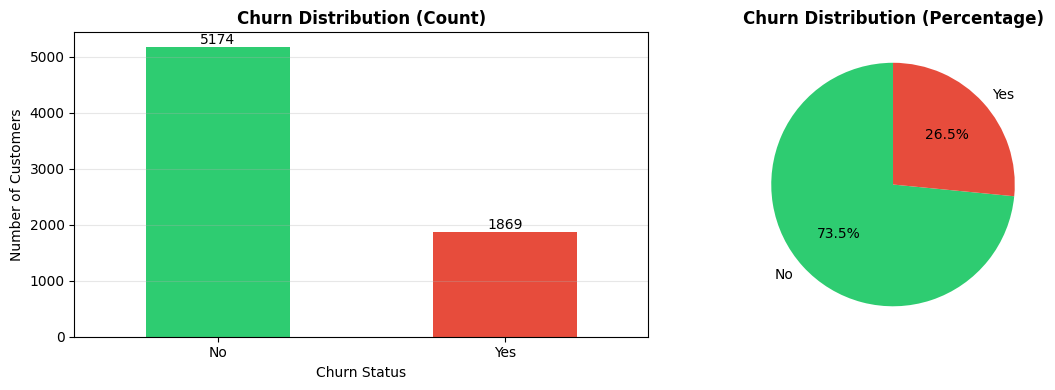

In [4]:
# Simple visualization
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
churn_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Churn Distribution (Count)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Churn Status')
ax1.set_ylabel('Number of Customers')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
ax2.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax2.set_title('Churn Distribution (Percentage)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---

## Observations

**Dataset Balance:**
- Imbalanced: 73.5% No vs 26.5% Yes (3:1 ratio)
- Need precision/recall metrics, may require sampling

**Cost Analysis:**
- CAC: 5-25x more than retention
- 1,869 churned = ~$3.7M lost revenue
- FN (miss churn) worse than FP (unnecessary offer)

**Leakage Risk:**
- TotalCharges: Verify calculation timing
- tenure, Contract: Valid predictors

---

---

# Business Feature Grouping

**Goal:** Organize features by business function and analyze their impact on churn and LTV

In [5]:
# Feature grouping dictionary
feature_groups = {
    'Demographics': [
        'gender',
        'SeniorCitizen', 
        'Partner',
        'Dependents'
    ],
    
    'Contract & Commitment': [
        'Contract',
        'tenure',
        'PaperlessBilling',
        'PaymentMethod'
    ],
    
    'Pricing & Revenue': [
        'MonthlyCharges',
        'TotalCharges'
    ],
    
    'Service Usage & Engagement': [
        'PhoneService',
        'MultipleLines',
        'InternetService',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies'
    ],
    
    'Target & Identifier': [
        'Churn',
        'customerID'
    ]
}

# Display groups
print("=" * 80)
print("BUSINESS FEATURE GROUPING")
print("=" * 80)

for group, columns in feature_groups.items():
    print(f"\n{group} ({len(columns)} features):")
    for col in columns:
        print(f"  - {col}")

print("\n" + "=" * 80)

BUSINESS FEATURE GROUPING

Demographics (4 features):
  - gender
  - SeniorCitizen
  - Partner
  - Dependents

Contract & Commitment (4 features):
  - Contract
  - tenure
  - PaperlessBilling
  - PaymentMethod

Pricing & Revenue (2 features):
  - MonthlyCharges
  - TotalCharges

Service Usage & Engagement (9 features):
  - PhoneService
  - MultipleLines
  - InternetService
  - OnlineSecurity
  - OnlineBackup
  - DeviceProtection
  - TechSupport
  - StreamingTV
  - StreamingMovies

Target & Identifier (2 features):
  - Churn
  - customerID



---

## Group Analysis

**Demographics** (4 features)
- Churn: Families stable, seniors tech issues
- LTV: Families longer tenure
- Model use: Moderate

**Contract** (4 features)  
- Churn: Contract strongest, tenure = commitment
- LTV: tenure × charges
- Model use: CRITICAL

**Pricing** (2 features)
- Churn: Price sensitivity
- LTV: Direct revenue
- Model use: CRITICAL for LTV

**Services** (9 features)
- Churn: Add-ons = switching friction
- LTV: Drives ARPU
- Model use: HIGH for churn/LTV, CRITICAL for engagement

---

## Recommendations

| Use Case | Must-Have | Nice-to-Have |
|----------|-----------|--------------|
| Churn | Contract, tenure, services | Demographics |
| LTV | tenure, MonthlyCharges | Services |
| Engagement | All service features | Payment method |

---

---

# Phase 1: Data Understanding Summary

**Dataset:** 7,043 telco customers, 21 features, 26.5% churn rate

**Completed:**
- Loaded and inspected raw data
- Mapped columns to business functions
- Identified 1 critical issue (TotalCharges type)
- Analyzed churn distribution (imbalanced 3:1)
- Grouped features for modeling strategy

**Key Findings:**
- Contract type expected strongest churn predictor
- 11 new customers (tenure=0) not yet billed
- Behavior features (services) > demographics
- LTV calculation needs tenure × MonthlyCharges

---

## What This Data CAN Tell Us

**Churn Prediction:**
- Which customer segments churn more (contract, tenure, services)
- Impact of service bundling on retention
- Price sensitivity patterns
- Early churn signals (new customers)

**Customer Value:**
- Revenue per customer (MonthlyCharges)
- Tenure-based LTV estimation
- High-value customer identification (ARPU)
- Service adoption patterns

**Engagement:**
- Add-on service usage (9 features)
- Digital adoption (paperless billing, payment method)
- Service portfolio diversity

---

## What This Data CANNOT Tell Us

**Missing Information:**
- WHY customers churn (no exit survey, complaints)
- Customer satisfaction scores
- Competitor offerings or pricing
- Service quality metrics (speed, uptime, support tickets)
- Marketing spend per customer
- Actual usage volume (GB used, call minutes)

**Time Limitations:**
- No historical snapshots (single point in time)
- Cannot track customer journey
- No seasonality analysis
- Contract renewal dates unknown

**Business Context:**
- Market conditions at time of data collection
- Regional differences (no geography)
- True CAC per customer
- Retention offer history

---

## Stated Assumptions

**1. Tenure as Time Proxy**
- Assumption: tenure (months with company) represents customer lifecycle stage
- Justification: Longer tenure = more invested, familiar with service
- Limitation: Doesn't account for contract gaps or service pauses
- Use case: Proxy for "stickiness" and relationship depth

**2. Engagement Inference**
- Assumption: Number of add-on services = engagement level
- Justification: Active service selection indicates product involvement
- Limitation: Doesn't measure actual usage intensity
- Alternative: Could use MonthlyCharges as engagement proxy (more services = higher bill)

**3. TotalCharges Calculation**
- Assumption: TotalCharges calculated at snapshot time (not post-churn)
- Risk: If calculated post-churn, it's leakage
- Mitigation: Will validate TotalCharges ≈ tenure × avg(MonthlyCharges) before modeling

**4. Churn Definition**
- Assumption: "Yes" in Churn = voluntary cancellation
- Unknown: Doesn't distinguish voluntary vs involuntary (non-payment)
- Impact: Model may conflate different churn types

---

## Ready for Phase 2 if...

**Data Quality:**
- [ ] TotalCharges type issue documented (YES - 11 empty strings identified)
- [ ] No unexpected missing values beyond TotalCharges (YES - all other columns clean)
- [ ] Churn target variable validated (YES - 26.5% churn, binary Yes/No)

**Business Understanding:**
- [ ] Feature groups defined (YES - 4 groups mapped)
- [ ] Churn cost implications understood (YES - FN > FP, high-cost problem)
- [ ] Leakage risks identified (YES - TotalCharges flagged for verification)

**Modeling Strategy:**
- [ ] Target variable confirmed (YES - Churn column)
- [ ] Class imbalance acknowledged (YES - need sampling/metrics strategy)
- [ ] Feature priorities set (YES - Contract/Services > Demographics)

**Documentation:**
- [ ] Column meanings documented (YES - business interpretation complete)
- [ ] Data quality audit complete (YES - all issues catalogued)
- [ ] Assumptions explicitly stated (YES - see above)

---

**STATUS: READY FOR PHASE 2**

**Next Phase:** Data Cleaning & Preprocessing
- Fix TotalCharges data type
- Handle 11 empty values (tenure=0 customers)
- Encode categorical variables
- Address class imbalance
- Create train/test split

---